# Arabic visual-description lab

This notebook mirrors the POC's image and video-description step. It loads an image or video, samples videos every 20 seconds, displays each sampled frame, and sends the frame to the configured vision model.

**Important boundary:** descriptions can report visible objects, counts, colours, placement, architectural details and readable text. They must not identify or name a person from a face. To test a name-based retrieval flow, use a source that has a readable lower-third, subtitle, title card, transcript, or trusted publisher metadata naming the person.

## 1. Select media

Set `INPUT_PATH` to any local image or video. The default uses a landmark image already included in the POC. Videos are sampled at the same `fps=1/N:start_time=0:round=up` grid used by the pipeline.

In [1]:
from datetime import datetime
from pathlib import Path
import json
import subprocess

ROOT = Path.cwd()
if not (ROOT / 'arabic_poc').exists():
    ROOT = ROOT.parent

# Replace this with your own local image or video.
INPUT_PATH = ROOT / 'data' / 'visual_samples' / 'king_abdul_aziz_gate.jpg'
FRAME_SECONDS = 20
assert INPUT_PATH.is_file(), f'File not found: {INPUT_PATH}'
assert FRAME_SECONDS > 0
print(f'Input: {INPUT_PATH}')


Input: /Users/ushnah.abbasi/RAG-Anything/data/visual_samples/king_abdul_aziz_gate.jpg


## 2. Load one image or sample a video

Frames are saved under `arabic_poc/notebook_frames/` so you can inspect or reuse them after the notebook finishes.

In [2]:
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp', '.webp'}
VIDEO_SUFFIXES = {'.mp4', '.mkv', '.mov', '.webm', '.avi'}

def command(*args):
    return subprocess.run(args, check=True, capture_output=True, text=True).stdout

def sample_media(path, interval):
    if path.suffix.lower() in IMAGE_SUFFIXES:
        return [(path, None)]
    if path.suffix.lower() not in VIDEO_SUFFIXES:
        raise ValueError('Choose an image or supported video file.')
    probe = json.loads(command('ffprobe', '-v', 'error', '-show_format', '-of', 'json', str(path)))
    duration = float(probe['format']['duration'])
    folder = ROOT / 'arabic_poc' / 'notebook_frames' / f'{path.stem}-{datetime.now():%Y%m%d-%H%M%S}'
    folder.mkdir(parents=True, exist_ok=False)
    command('ffmpeg', '-v', 'error', '-i', str(path), '-vf',
            f'fps=1/{interval}:start_time=0:round=up,scale=640:-2', str(folder / '%06d.jpg'))
    frames = [(frame, index * interval) for index, frame in enumerate(sorted(folder.glob('*.jpg')))
              if index * interval < duration]
    return frames

frames = sample_media(INPUT_PATH, FRAME_SECONDS)
print(f'{len(frames)} image/frame input(s)')
[(path.name, timestamp) for path, timestamp in frames]


1 image/frame input(s)


[('king_abdul_aziz_gate.jpg', None)]

### Image

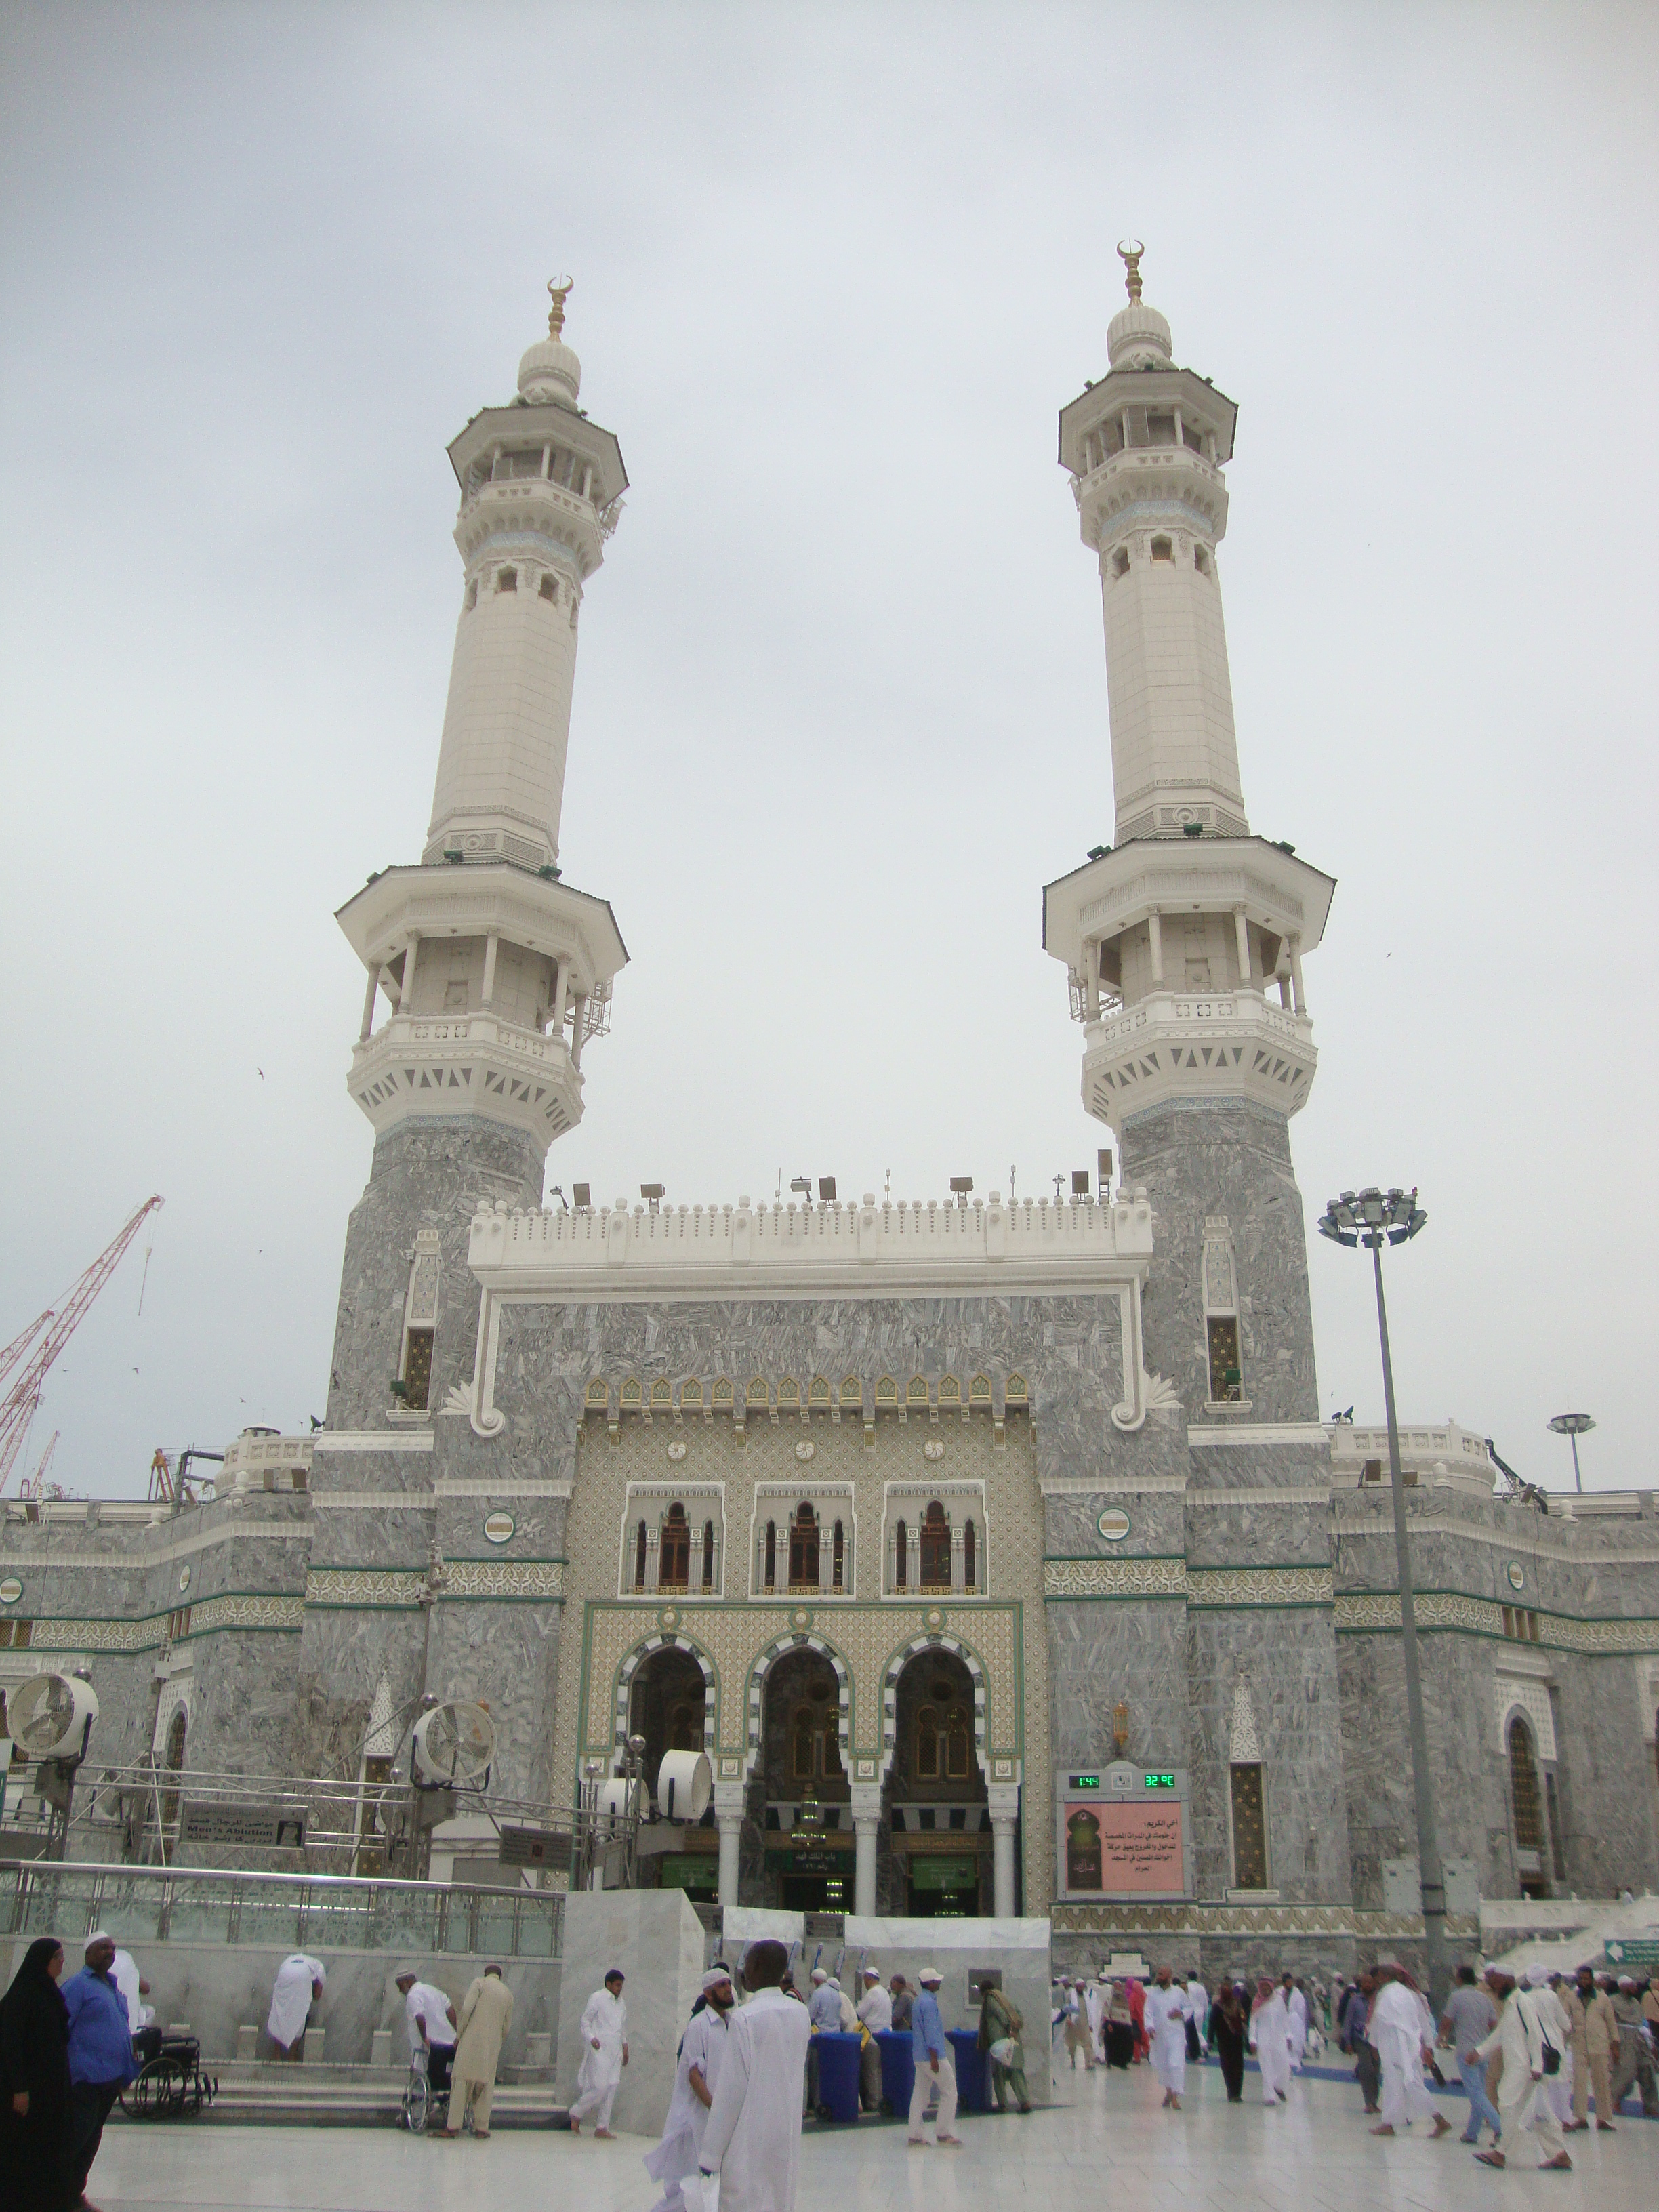

In [3]:
from IPython.display import display, Image as DisplayImage, Markdown

for path, timestamp in frames:
    label = 'Image' if timestamp is None else f'Video frame at {timestamp:.0f}s'
    display(Markdown(f'### {label}'))
    display(DisplayImage(filename=str(path), width=720))


## 3. Describe the frames

The adapter uses the POC configuration in `.env`: remote Gemma when `VISION_BACKEND=remote`, or local Qwen2.5-VL when `VISION_BACKEND=local`. The description request asks for scene, visible objects/count, visible text, placement/colours and architectural details. A count should be reported only when the object is fully visible and unambiguous.

In [4]:
from arabic_poc.models import image_parser
from arabic_poc.remote import enabled

VISION_MODEL = 'models/qwen2.5-vl-3b'
vision = image_parser(VISION_MODEL, describe=True)
provider = 'remote vision model' if enabled('vision') else 'local Qwen2.5-VL'
print(f'Description provider: {provider}')


ModuleNotFoundError: No module named 'arabic_poc'

In [ ]:
results = []
for path, timestamp in frames:
    description = vision.parse_image(path)[0]['text']
    row = {'frame': str(path), 'timestamp_seconds': timestamp, 'description': description}
    results.append(row)
    display(Markdown(f"### {'Image' if timestamp is None else f'{timestamp:.0f}s'}"))
    display(Markdown(description))

results


## 4. Add trusted context separately

Do not ask the model to infer a person's identity from appearance. If a source already names a speaker or person, keep that claim separate as trusted context and record where it came from. This is what the retrieval system should search for named-person queries.

In [ ]:
trusted_context = {
    'person_name': None,  # Set only from a publisher title, caption, visible lower-third, or transcript.
    'provenance': None,   # Example: 'publisher_metadata' or 'visible_lower_third'.
    'source_url': None,
}

assert trusted_context['person_name'] is None or trusted_context['provenance'], (
    'A name needs provenance; do not derive it from a face.'
)
trusted_context


## 5. Save results for review

The JSON file is a review artifact. It is not automatically added to the RAG index. Compare each description with its displayed frame before promoting it into a production corpus.

In [ ]:
output_path = ROOT / 'arabic_poc' / 'validation' / f'{INPUT_PATH.stem}-visual-lab.json'
output_path.write_text(json.dumps({
    'input': str(INPUT_PATH),
    'frame_seconds': FRAME_SECONDS,
    'description_provider': provider,
    'trusted_context': trusted_context,
    'results': results,
}, ensure_ascii=False, indent=2), encoding='utf-8')
print(f'Saved: {output_path}')
